# Vietnam’s Industrialization: Growth, Trade-offs, and Hidden Costs

## Objective
This notebook analyzes Vietnam’s industrialization within ASEAN and examines the trade-offs between growth, environment, and human well-being.

## Key Questions
1. Where does Vietnam stand in ASEAN industrialization?
2. What environmental costs accompany growth?
3. Is Vietnam sacrificing health for growth?

## Scope
- Countries: Full ASEAN (10 countries)
- Time: 2000–2025
- Focus: Vietnam (highlighted)

## Indicators
- Industry, value added (% of GDP)
- CO2 emissions per capita
- PM2.5 air pollution
- Life expectancy
- Under-5 mortality

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

DATA PROCESSING

In [9]:
df_raw = pd.read_csv("Data1.csv")

print("Columns:")
print(df_raw.columns.tolist())

df_raw.head()

Columns:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]']


,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Viet Nam,VNM,"Industry (including construction), value added...",NV.IND.TOTL.ZS,36.730775,38.129422,38.486679,39.470008,40.208750,38.131140,...,34.115229,35.390364,36.542433,36.803137,36.743713,37.3915192469302,38.4823612398341,37.5815697548824,37.6414652034249,..
1,Viet Nam,VNM,Carbon intensity of GDP (kg CO2e per constant ...,EN.GHG.CO2.RT.GDP.KD,0.604492,0.625182,0.692092,0.687862,0.757304,0.770204,...,0.876757,0.839818,0.961612,1.068523,1.075190,1.01181276155185,0.953936159714234,1.03127470286166,1.06180348658809,..
2,Viet Nam,VNM,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,0.732763,0.796360,0.927761,0.975900,1.144244,1.240000,...,2.380902,2.408712,2.931267,3.463165,3.551533,3.39788716841419,3.45101965872917,3.89354026267807,4.26605675468195,..
3,Viet Nam,VNM,"PM2.5 air pollution, mean annual exposure (mic...",EN.ATM.PM25.MC.M3,27.233264,27.272454,27.372916,27.466908,27.486688,27.364514,...,20.330446,18.579780,20.163018,20.831787,20.801064,..,..,..,..,..
4,Viet Nam,VNM,"Mortality rate, under-5 (per 1,000 live births)",SH.DYN.MORT,29.800000,28.600000,27.400000,26.500000,25.700000,25.000000,...,21.800000,21.500000,21.400000,21.200000,21.000000,20.7,20.4,20,..,..


## Data Transformation

The dataset is originally in **wide format** (years as columns).

We convert it into:
1. Long format (Year becomes a column)
2. Pivot format (each indicator becomes a column)

This enables time-series analysis and visualization.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_raw = pd.read_csv("Data1.csv")

# Xem columns
print(df_raw.columns.tolist())

['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]']


In [3]:
df_long = df_raw.melt(
    id_vars=["Country Name", "Series Name"],
    var_name="Year",
    value_name="Value"
)
df_long["Year"] = df_long["Year"].str.extract(r'(\d{4})')
df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")
df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
df_long = df_long.dropna(subset=["Year", "Value"])
df_pivot = df_long.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()
df = df_pivot.rename(columns={
    "Country Name": "Country",
    "Industry (including construction), value added (% of GDP)": "Industry (% GDP)",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)": "CO2 per capita",
    "PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)": "PM2.5",
    "Life expectancy at birth, total (years)": "Life expectancy",
    "Mortality rate, under-5 (per 1,000 live births)": "Under-5 mortality"
})
df["Country"] = df["Country"].replace({
    "Viet Nam": "Vietnam"
})
asean = [
    "Vietnam", "Thailand", "Malaysia", "Indonesia", "Philippines",
    "Singapore", "Cambodia", "Lao PDR", "Myanmar", "Timor-Leste"
]

df_asean = df[df["Country"].isin(asean)].copy()

## Visualization Strategy

- Grey lines → ASEAN context
- Red line → Vietnam (focus)
- Selected countries → comparison group

This avoids clutter while preserving regional context.

## Question 1: Where does Vietnam stand in ASEAN industrialization?

To understand Vietnam’s economic structure, we analyze the share of industry in GDP.

This indicator reflects:
- The level of industrial development
- The stage of structural transformation (agriculture → industry → services)

We compare Vietnam with all ASEAN countries over time to determine whether it is:
- Still industrializing
- Or transitioning to a post-industrial economy

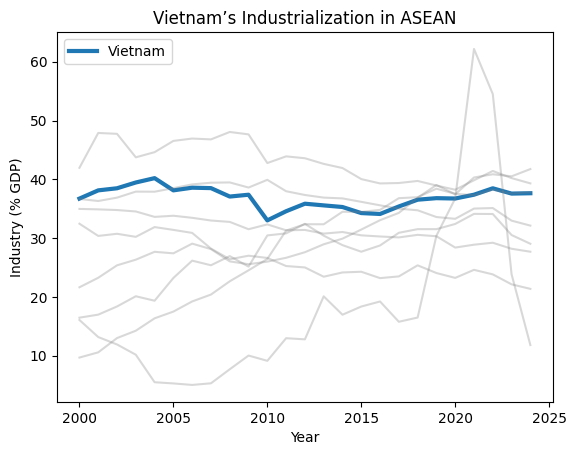

In [4]:
plt.figure()

for country in asean:
    subset = df_asean[df_asean["Country"] == country]

    if country == "Vietnam":
        plt.plot(
            subset["Year"],
            subset["Industry (% GDP)"],
            linewidth=3,
            label="Vietnam"
        )
    else:
        plt.plot(
            subset["Year"],
            subset["Industry (% GDP)"],
            color="gray",
            alpha=0.3
        )

plt.xlabel("Year")
plt.ylabel("Industry (% GDP)")
plt.title("Vietnam’s Industrialization in ASEAN")

plt.legend()
plt.show()

### Insight

Vietnam shows a strong upward trend in the share of industry, indicating rapid industrial expansion.

In contrast:
- Countries like Thailand and Malaysia have stabilized or reduced their industrial share
- Lower-income ASEAN countries remain below Vietnam

This suggests that Vietnam is currently in an **active industrialization phase**,  
positioning itself as a key manufacturing hub in the region.

Unlike high-income economies, Vietnam has not yet transitioned to a service-dominated structure.

## Question 2: What environmental costs accompany industrial growth?

Industrialization often leads to increased environmental pressure.

To examine this trade-off, we analyze:
- CO2 emissions per capita (carbon output)
- PM2.5 air pollution (air quality)

These indicators capture both:
- Long-term environmental impact (climate change)
- Immediate health risks (air pollution)

We compare Vietnam’s trends with ASEAN to understand whether growth comes at an environmental cost.

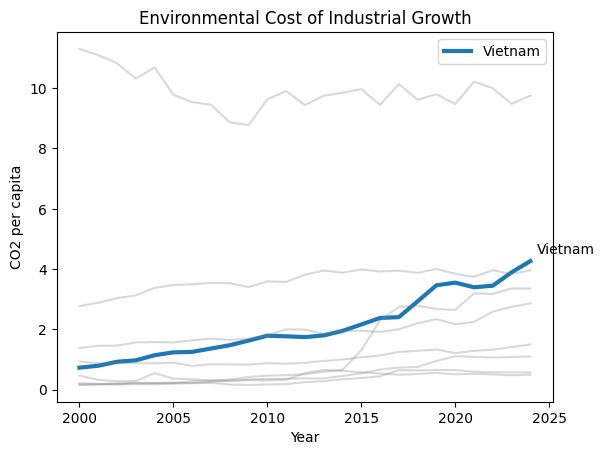

In [33]:
plt.figure()

for country in asean:
    subset = df_asean[df_asean["Country"] == country]

    if country == "Vietnam":
        plt.plot(
            subset["Year"],
            subset["CO2 per capita"],
            linewidth=3,
            label="Vietnam"
        )
    else:
        plt.plot(
            subset["Year"],
            subset["CO2 per capita"],
            color="gray",
            alpha=0.3
        )

vn = df_asean[df_asean["Country"] == "Vietnam"]
x_last = vn["Year"].max()
y_last = vn[vn["Year"] == x_last]["CO2 per capita"].values[0]

plt.annotate("Vietnam", (x_last, y_last), textcoords="offset points", xytext=(5,5))

plt.xlabel("Year")
plt.ylabel("CO2 per capita")
plt.title("Environmental Cost of Industrial Growth")

plt.legend()
plt.show()

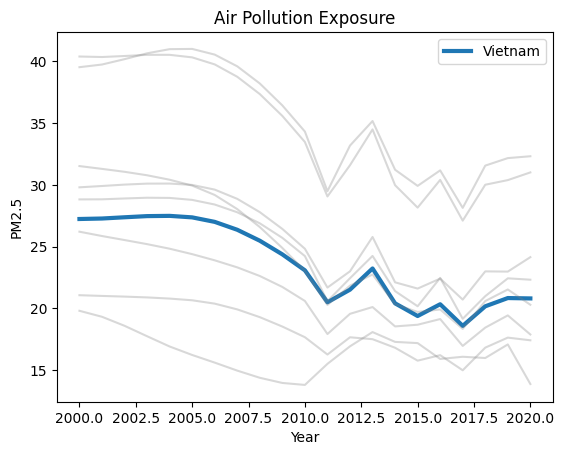

In [25]:
plt.figure()

for country in asean:
    subset = df_asean[df_asean["Country"] == country]

    if country == "Vietnam":
        plt.plot(
            subset["Year"],
            subset["PM2.5"],
            linewidth=3,
            label="Vietnam"
        )
    else:
        plt.plot(
            subset["Year"],
            subset["PM2.5"],
            color="gray",
            alpha=0.3
        )

vn = df_asean[df_asean["Country"] == "Vietnam"]
x_last = vn["Year"].max()
y_last = vn[vn["Year"] == x_last]["PM2.5"].values[0]

plt.annotate("Vietnam", (x_last, y_last), textcoords="offset points", xytext=(5,5))

plt.xlabel("Year")
plt.ylabel("PM2.5")
plt.title("Air Pollution Exposure")

plt.legend()
plt.show()

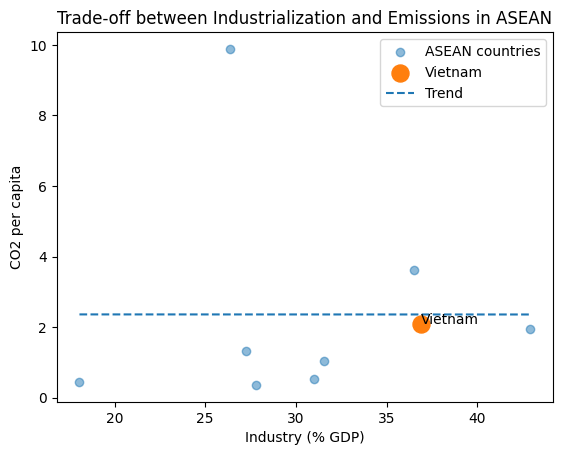

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

df_avg = df_asean.groupby("Country").mean(numeric_only=True).reset_index()

# --- ASEAN context ---
plt.scatter(
    df_avg["Industry (% GDP)"],
    df_avg["CO2 per capita"],
    label="ASEAN countries",
    alpha=0.5
)

# --- Vietnam highlight ---
vn = df_avg[df_avg["Country"] == "Vietnam"]

plt.scatter(
    vn["Industry (% GDP)"],
    vn["CO2 per capita"],
    s=150,
    label="Vietnam"
)

plt.text(
    vn["Industry (% GDP)"].values[0],
    vn["CO2 per capita"].values[0],
    "Vietnam"
)

x = df_avg["Industry (% GDP)"]
y = df_avg["CO2 per capita"]

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

x_line = np.linspace(x.min(), x.max(), 100)

plt.plot(x_line, trend(x_line), linestyle="--", label="Trend")

plt.xlabel("Industry (% GDP)")
plt.ylabel("CO2 per capita")
plt.title("Trade-off between Industrialization and Emissions in ASEAN")

plt.legend()
plt.show()

### Insight

As Vietnam’s industrial share increases, both CO2 emissions and air pollution rise significantly.

Compared to other ASEAN countries:
- Vietnam shows a steeper increase in emissions
- Pollution levels are closely tied to industrial expansion

This indicates that Vietnam’s growth is still **carbon-intensive** and environmentally costly.

Instead of focusing on trends over time, we analyze cross-country patterns to identify whether Vietnam follows a broader regional pattern. The country follows a **“grow first, clean later”** development path, typical of late industrializers.

## Question 3: Is Vietnam sacrificing health for economic growth?

While industrialization increases pollution, its impact on human well-being is not always direct.

To evaluate this, we analyze:
- Life expectancy (overall health outcome)
- Under-5 mortality rate (health system effectiveness)

These indicators help determine whether environmental degradation negatively affects population health.

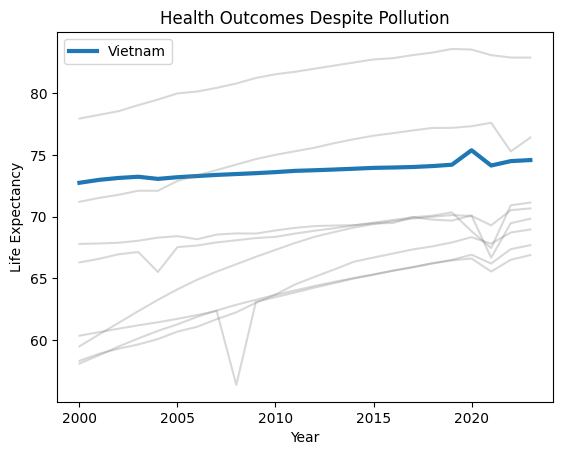

In [26]:
plt.figure()

for country in asean:
    subset = df_asean[df_asean["Country"] == country]

    if country == "Vietnam":
        plt.plot(
            subset["Year"],
            subset["Life expectancy"],
            linewidth=3,
            label="Vietnam"
        )
    else:
        plt.plot(
            subset["Year"],
            subset["Life expectancy"],
            color="gray",
            alpha=0.3
        )

vn = df_asean[df_asean["Country"] == "Vietnam"]
x_last = vn["Year"].max()
y_last = vn[vn["Year"] == x_last]["Life expectancy"].values[0]

plt.annotate("Vietnam", (x_last, y_last), textcoords="offset points", xytext=(5,5))

plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.title("Health Outcomes Despite Pollution")

plt.legend()
plt.show()

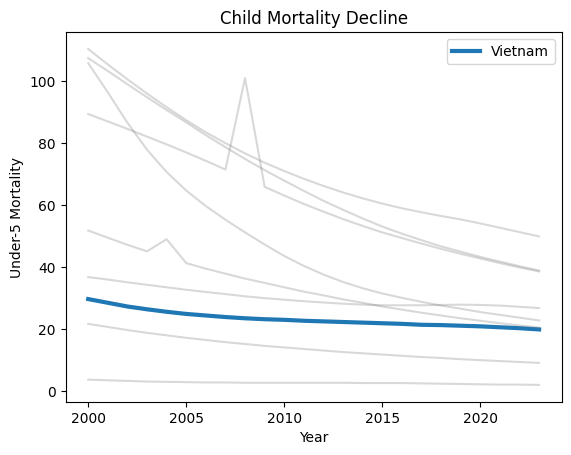

In [27]:
plt.figure()

for country in asean:
    subset = df_asean[df_asean["Country"] == country]

    if country == "Vietnam":
        plt.plot(
            subset["Year"],
            subset["Under-5 mortality"],
            linewidth=3,
            label="Vietnam"
        )
    else:
        plt.plot(
            subset["Year"],
            subset["Under-5 mortality"],
            color="gray",
            alpha=0.3
        )

vn = df_asean[df_asean["Country"] == "Vietnam"]
x_last = vn["Year"].max()
y_last = vn[vn["Year"] == x_last]["Under-5 mortality"].values[0]

plt.annotate("Vietnam", (x_last, y_last), textcoords="offset points", xytext=(5,5))

plt.xlabel("Year")
plt.ylabel("Under-5 Mortality")
plt.title("Child Mortality Decline")

plt.legend()
plt.show()

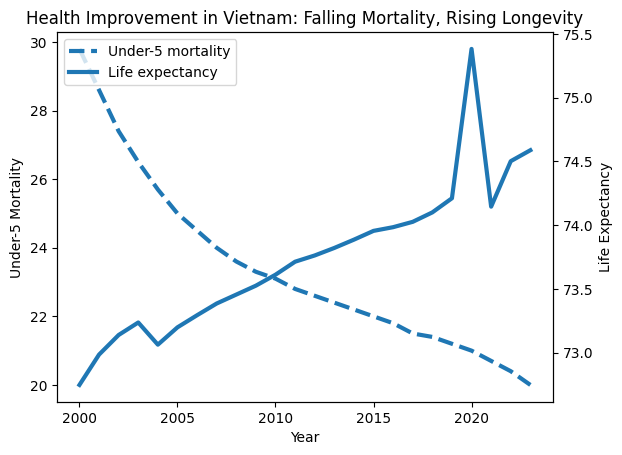

In [6]:
plt.figure()

vn = df_asean[df_asean["Country"] == "Vietnam"].sort_values("Year")

# --- Trục 1: Under-5 mortality ---
ax1 = plt.gca()

ax1.plot(
    vn["Year"],
    vn["Under-5 mortality"],
    linewidth=3,
    linestyle="--",
    label="Under-5 mortality"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Under-5 Mortality")

# --- Trục 2: Life expectancy ---
ax2 = ax1.twinx()

ax2.plot(
    vn["Year"],
    vn["Life expectancy"],
    linewidth=3,
    label="Life expectancy"
)

ax2.set_ylabel("Life Expectancy")

# --- Title ---
plt.title("Health Improvement in Vietnam: Falling Mortality, Rising Longevity")

# --- Legend chung ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

plt.legend(lines1 + lines2, labels1 + labels2)

plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/var/folders/35/gq9mrnjj4dlfw712zx6m4hzw0000gn/T/ipykernel_84697/1374780069.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("$PM_{2.5}$ Concentration ($\mu g/m^3$)", color='grey', fontweight='bold')


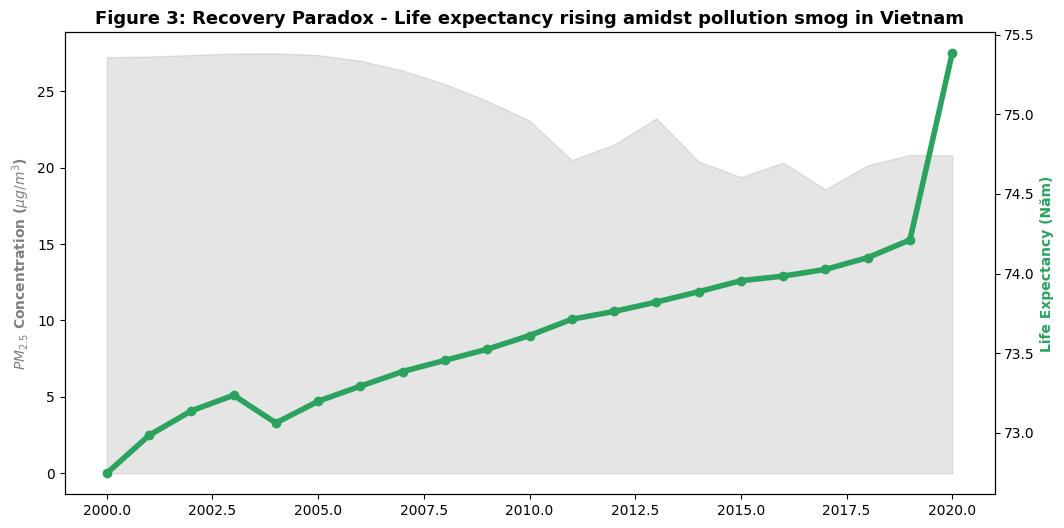

In [18]:
vn = df_asean[df_asean['Country'] == 'Vietnam'].dropna(subset=['PM2.5', 'Life expectancy'])
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Trục 1: Vùng sương mù ô nhiễm (Area Chart)
ax1.fill_between(vn['Year'], vn['PM2.5'], color='grey', alpha=0.2, label='$PM_{2.5}$ Concentration')
# Trục 2: Thành quả tuổi thọ (Line Chart)
ax2.plot(vn['Year'], vn['Life expectancy'], color='#2CA25F', linewidth=4, marker='o', markersize=6, label='Life Expectancy')

ax1.set_ylabel("$PM_{2.5}$ Concentration ($\mu g/m^3$)", color='grey', fontweight='bold')
ax2.set_ylabel("Life Expectancy (Năm)", color='#2CA25F', fontweight='bold')
plt.title("Figure 3: Recovery Paradox - Life expectancy rising amidst pollution smog in Vietnam", fontweight='bold', fontsize=13)
plt.show()

### Insight

Despite rising pollution levels:
- Life expectancy in Vietnam continues to increase
- Under-5 mortality declines significantly

This suggests that improvements in:
- Healthcare systems
- Public policy
- Social investment

are offsetting the negative effects of environmental degradation.

These two trends reinforce each other, indicating significant progress in healthcare and living standards.

1. **Contrasting trends:** Although $PM_{2.5}$ concentration in Vietnam remains at hazardous levels (around $20 \mu g/m^3$, double the WHO safe limit), average life expectancy has steadily increased from 73 to 75 years.
2. **Fiscal Space Hypothesis:** This serves as evidence for the **"Paying with social budget"** model. Profits accumulated from industrialization (question 1) have provided financial resources for the Government to invest in preventive healthcare, vaccines, and clean water. Current medical advances are temporarily "overcoming" the negative environmental impacts, but this is a fragile equilibrium that demands attention in the future.

This strengthens the argument that: even under environmental pressure, human development continues to improve.
Vietnam is not simply trading health for growth, but instead follows a model of:

**Industrial Growth → Environmental Cost → Social Compensation**

## Final Conclusion

Vietnam is undergoing rapid industrialization and positioning itself as a key manufacturing hub in ASEAN.

However, this growth comes with clear environmental costs:
- Rising emissions
- Increasing air pollution

At the same time, human development indicators continue to improve due to strong social investments.

This creates a unique development pattern:

**Fast Growth + Environmental Pressure + Social Buffering**

## Implication

To sustain long-term growth and escape the middle-income trap, Vietnam must:
- Transition toward cleaner production
- Invest in a knowledge-based economy
- Improve institutional quality